# Система прогнозирования продаж для «Прилавка»

## Описание задачи

Ваш клиент — компания «Прилавок», новая сеть дарксторов в России, специализирующаяся на быстрой доставке продуктов и товаров повседневного спроса. Компания работает с 2023 года и управляет более чем 45 дарксторами.

**Бизнес-проблема**

Эффективность дарксторов критически зависит от точности управления запасами. Текущая система планирования закупок работает на субъективных оценках аналитиков, что приводит к разным проблемам:
- К дефициту товаров в пиковые периоды (недополучение 3–5% выручки).
- К избыточным запасам и списаниям продуктов с коротким сроком годности (2–3% от выручки).
- К неэффективному использованию времени аналитиков (15–20 часов в неделю на ручное планирование).

**Цель проекта**

Разработать автоматизированную систему прогнозирования недельных продаж для каждого отдела во всех дарксторах с использованием машинного обучения (модель CatBoost). Система будет работать в режиме пакетного внедрения с недельным циклом: модель будет переобучаться каждое воскресенье вечером, а к понедельнику утром прогнозы будут готовы для передачи в систему планирования закупок.

## Описание данных

Для работы доступны исторические данные о продажах за февраль 2023 — октябрь 2025, организованные в виде нескольких таблиц в PostgreSQL:

1. Таблица `sales` — исторические данные о продажах:
   - `Store` — номер даркстора (1–45).
   - `Dept` — номер отдела внутри даркстора (1–99).
   - `Date` — неделя (дата начала недели).
   - `Weekly_Sales` — недельные продажи (руб., целевая переменная).
   - `IsHoliday` — признак праздничной недели.

2. Таблица `stores` — информация о дарксторах:
   - `Store` — номер даркстора.
   - `Type` — тип даркстора (A, B, C).
   - `Size` — размер даркстора в условных единицах.

3. Таблица `features` — внешние факторы:
   - `Store`, `Date` — идентификаторы.
   - `Temperature` — средняя температура за неделю.
   - `Fuel_Price` — средняя цена бензина.
   - `MarkDown1-5` — факторы рекламных акций и скидок.
   - `CPI` — индекс потребительских цен.
   - `Unemployment` — уровень безработицы.

4. Таблица `plan` — данные для инференса (ноябрь 2025 — июль 2026), содержит те же столбцы, что и `sales`, кроме `Weekly_Sales`.

## План работы

Проект состоит из двух частей. В этом ноутбуке вы выполните первую:

1. Первичный анализ и очистка данных.
2. Предобработка и создание признаков.
3. Мониторинг стабильности признаков (PSI).
4. Обучение модели CatBoost и оценка качества.



In [5]:
from phik import phik
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import shap

from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import psycopg2

import io
import pickle
import boto3
import os
from dotenv import load_dotenv
load_dotenv()

import warnings
warnings.filterwarnings("ignore")

C:\Users\bekishev\Desktop\project_5\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Фиксируем `random_state` для воспроизводимости результатов.

In [7]:
RANDOM_STATE = 42

In [8]:
# !pip freeze > reqiurements.txt

### Шаг 1. Первичный анализ данных

**Задача:** подключитесь к базе данных PostgreSQL и загрузите данные для анализа.

**Важно:** не храните креды в коде! Используйте переменные окружения или Airflow Variables и Connections.

In [11]:
DB_NAME = os.getenv('DB_NAME')
DB_HOST = os.getenv('DB_HOST')
DB_PASS = os.getenv('DB_PASS')
DB_PORT = os.getenv('DB_PORT')
DB_USER = os.getenv('DB_USER')

**Задача:** загрузите три таблицы из PostgreSQL: `sales`, `stores`, `features`.

Используйте SQL-запросы для загрузки данных через функцию `pd.read_sql_query()`.

In [13]:
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [14]:
with engine.connect() as conn, conn.begin():
    df_sales = pd.read_sql_query("SELECT * FROM sales", conn)
    df_stores = pd.read_sql_query("SELECT * FROM stores", conn)
    df_features = pd.read_sql_query("SELECT * FROM features", conn)
    df_plan = pd.read_sql_query("SELECT * FROM plan", conn)

In [15]:
all_tables = {
    'sales' : df_sales,
    'stores': df_stores,
    'features' : df_features,
    'plan' : df_plan
}

In [16]:
for name, table in all_tables.items():
    print(f'Таблица {name}')
    print(table.info())
    print(table.describe(), '\n')
    print('*' * 60, '\n')

Таблица sales
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   weekly_sales  421570 non-null  float64
 4   is_holiday    421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None
               store           dept   weekly_sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000 

*****************************************

In [17]:
print(f"Период дат в таблице sales: {df_sales['date'].min()} - {df_sales['date'].max()}")
print(f"Период дат в таблице features: {df_features['date'].min()} - {df_features['date'].max()}")
print(f"Период дат в таблице plan: {df_plan['date'].min()} - {df_plan['date'].max()}")

Период дат в таблице sales: 2023-02-05 - 2025-10-26
Период дат в таблице features: 2023-02-05 - 2025-10-26
Период дат в таблице plan: 2025-11-02 - 2026-07-26


Было выгружено 4 таблицы:
  - sales : 5 столбцов и 421_570 записей - исторические данные о продажах за период с февраля 2023 по октябрь 2025
  - stores : 3 столбца и 45 записей - информация о дарксторах
  - features : 12 столбцов и 421_570 записей - исторические данные, связанные с внешними признаками за период с февраля 2023 по октябрь 2025
  - plan : 4 столбца и 115_064 записи - данные для инференса за период с ноября 2025 по июль 2026

**Задача:** обработайте пропуски и дубликаты в каждой таблице.

Рекомендации по обработке пропусков:
- Для непрерывных переменных — заполнить средним значением.
- Для категориальных переменных — заполнить модой.
- Полные дубликаты строк — удалить.

Перед обработкой изучите структуру пропусков и их причины.

In [20]:
for name, table in all_tables.items():
    print(f"Таблица {name}")
    print(f"Количество дубликатов в таблице: {table.duplicated().sum()}")
    print('Количество пустых строк для каждого столбца:')
    print(table.isna().sum())
    print('\n', '-' * 60, '\n')

Таблица sales
Количество дубликатов в таблице: 0
Количество пустых строк для каждого столбца:
store           0
dept            0
date            0
weekly_sales    0
is_holiday      0
dtype: int64

 ------------------------------------------------------------ 

Таблица stores
Количество дубликатов в таблице: 0
Количество пустых строк для каждого столбца:
store    0
type     0
size     0
dtype: int64

 ------------------------------------------------------------ 

Таблица features
Количество дубликатов в таблице: 0
Количество пустых строк для каждого столбца:
store                0
dept                 0
date                 0
temperature          0
fuel_price           0
factor1              0
factor2         310322
factor3         284479
factor4         286603
factor5         270138
cpi                  0
unemployment         0
dtype: int64

 ------------------------------------------------------------ 

Таблица plan
Количество дубликатов в таблице: 0
Количество пустых строк для каждо

Полных дубликатов в данных не обнаружено  


В таблице features в столбцах, обозначающих факторы рекламных акций (factor3-factor-5) обнаружены пустые значения, которые согласно рекомендации следует заполнить средним значением

In [22]:
# Заполняем пропуски средним
for col in df_features.select_dtypes(include='number').columns:
    df_features[col] = df_features[col].fillna(df_features[col].mean())

In [23]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   temperature   421570 non-null  float64
 4   fuel_price    421570 non-null  float64
 5   factor1       421570 non-null  float64
 6   factor2       421570 non-null  float64
 7   factor3       421570 non-null  float64
 8   factor4       421570 non-null  float64
 9   factor5       421570 non-null  float64
 10  cpi           421570 non-null  float64
 11  unemployment  421570 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 38.6+ MB


**Задача:** визуализируйте распределение продаж по времени (по месяцам и неделям).

Цель: выявить визуально наличие сезонности в данных. Обратите внимание:
- На периодические всплески (праздники, выходные).
- На общий тренд (рост и спад продаж).
- На аномальные периоды.

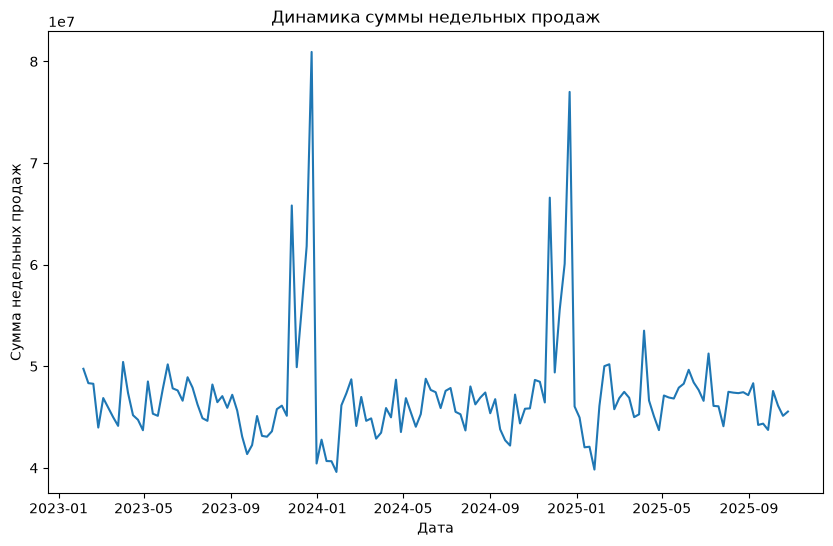

In [25]:
grouped_by_week = df_sales.groupby('date')['weekly_sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_by_week, x='date', y='weekly_sales')
plt.title('Динамика суммы недельных продаж')
plt.ylabel('Сумма недельных продаж')
plt.xlabel('Дата')
plt.show()

Во второй половине года, по мере приближения к новому году, динамика суммы недельных продаж стремительно увелчивается, и сразу же после наступления нового года - стремительно падает. В целом, если абстрагироваться от этих аномалий, то можно сделать вывод, что сумма недельных продаж колеблиться примерно на одном уровне.

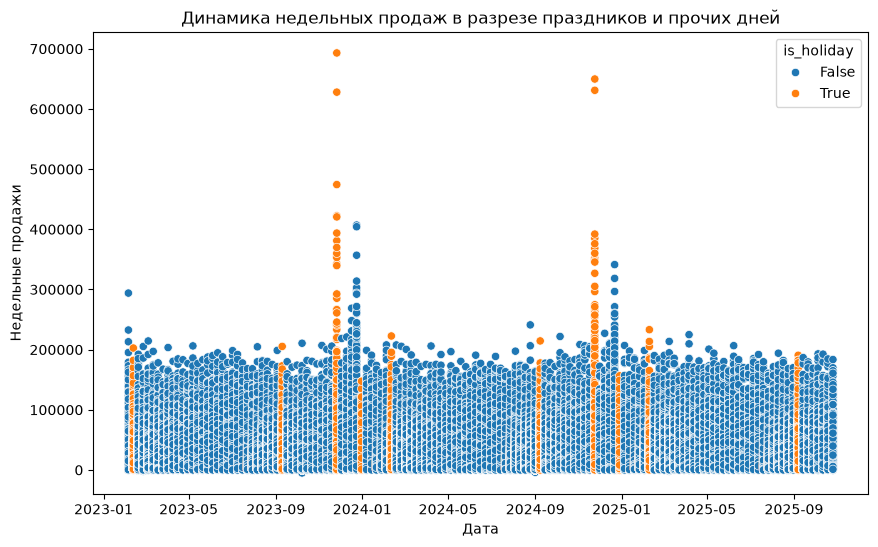

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sales, x='date', y='weekly_sales', hue='is_holiday')
plt.title('Динамика недельных продаж в разрезе праздников и прочих дней')
plt.xlabel('Дата')
plt.ylabel('Недельные продажи')
plt.show()

В большую часть праздников недельные продажи примерно соответствуют значениям продаж в прочие дни. Однако, 1 раз в год, ближе к новому году, наблюдается аномальные значения продаж.

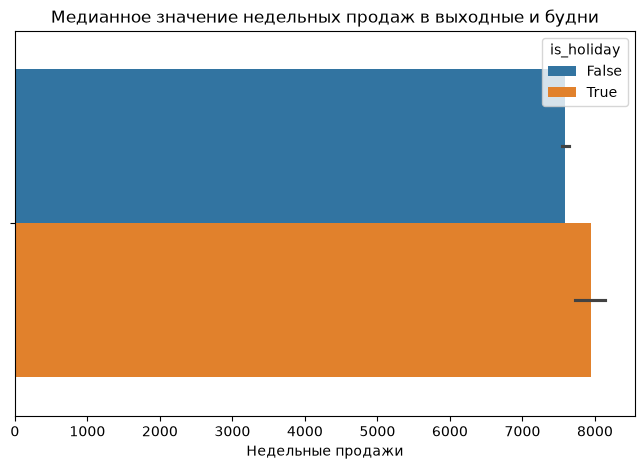

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_sales, x='weekly_sales', hue='is_holiday', estimator='median')
plt.title('Медианное значение недельных продаж в выходные и будни')
plt.xlabel('Недельные продажи')
plt.show()

Медианное значение недельных продаж оказывается немного выше и нестабильней относительно продаж в прочие дни.

**Задача:** объедините три таблицы в одну для дальнейшего анализа.

Используйте операции `merge()` для соединения таблиц по общим ключам.

In [32]:
df = df_sales.merge(df_stores, on='store', how='left')
df = df.merge(df_features, on=['date', 'store', 'dept'], how='left')

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   weekly_sales  421570 non-null  float64
 4   is_holiday    421570 non-null  bool   
 5   type          421570 non-null  str    
 6   size          421570 non-null  int64  
 7   temperature   421570 non-null  float64
 8   fuel_price    421570 non-null  float64
 9   factor1       421570 non-null  float64
 10  factor2       421570 non-null  float64
 11  factor3       421570 non-null  float64
 12  factor4       421570 non-null  float64
 13  factor5       421570 non-null  float64
 14  cpi           421570 non-null  float64
 15  unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(1), str(1)
memory usage: 48.6+ MB


In [34]:
df

,store,dept,date,weekly_sales,is_holiday,type,size,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,24924.50,False,A,151315,42.31,2.572,7028.800000,3334.628621,1439.421384,3383.168256,4628.975079,211.096358,8.106
1,29,5,2023-02-05,15552.08,False,B,93638,24.36,2.788,7028.800000,3334.628621,1439.421384,3383.168256,4628.975079,131.527903,10.064
2,29,6,2023-02-05,3200.22,False,B,93638,24.36,2.788,7028.800000,3334.628621,1439.421384,3383.168256,4628.975079,131.527903,10.064
3,29,7,2023-02-05,10820.05,False,B,93638,24.36,2.788,7028.800000,3334.628621,1439.421384,3383.168256,4628.975079,131.527903,10.064
4,29,8,2023-02-05,20055.64,False,B,93638,24.36,2.788,7028.800000,3334.628621,1439.421384,3383.168256,4628.975079,131.527903,10.064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,40,87,2025-10-26,24638.96,False,A,155083,49.65,3.917,10181.886605,55.980000,0.280000,486.810000,1389.060000,138.728161,4.145
421566,19,30,2025-10-26,3740.12,False,A,203819,56.49,4.071,11970.746689,90.070000,1439.421384,904.340000,1665.770000,138.728161,7.992
421567,19,31,2025-10-26,3128.17,False,A,203819,56.49,4.071,11970.746689,90.070000,1439.421384,904.340000,1665.770000,138.728161,7.992
421568,19,33,2025-10-26,5740.14,False,A,203819,56.49,4.071,11970.746689,90.070000,1439.421384,904.340000,1665.770000,138.728161,7.992


**Задача:** оцените корреляцию целевой переменной `Weekly_Sales` с другими признаками.

Используйте метод `.corr()` для расчёта корреляционной матрицы. Ответьте на вопросы:
- Какие признаки сильнее всего коррелируют с продажами?
- Есть ли сильно коррелирующие между собой признаки (мультиколлинеарность)?

interval columns not set, guessing: ['store', 'dept', 'weekly_sales', 'size', 'temperature', 'fuel_price', 'factor1', 'factor2', 'factor3', 'factor4', 'factor5', 'cpi', 'unemployment']


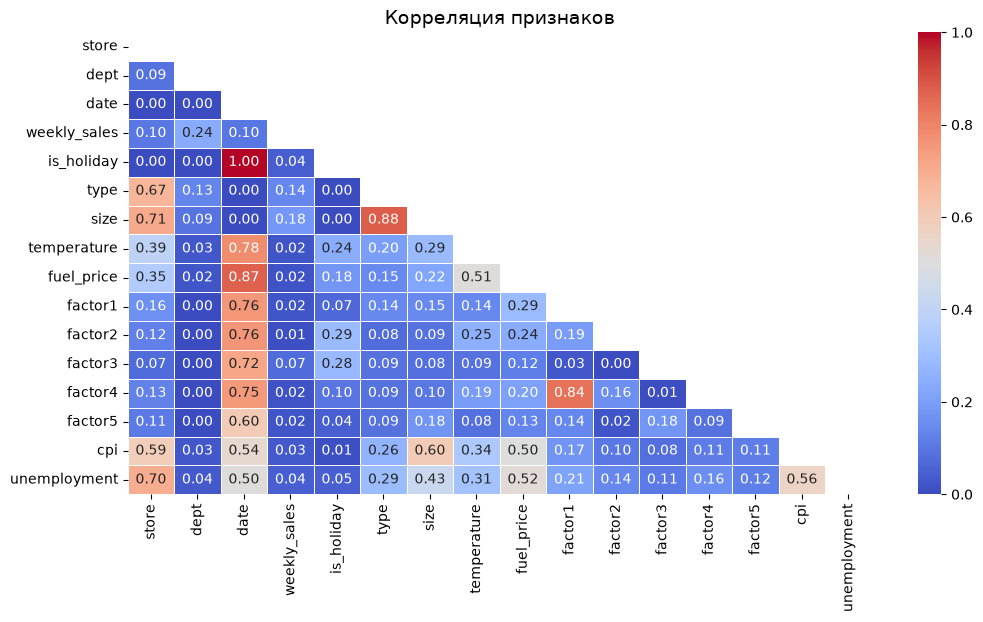

In [37]:
interval_cols = ['store', 'dept', 'weekly_sales', 'size', 'temperature',
                 'fuel_price', 'factor1', 'factor2', 'factor3',
                 'factor4', 'factor5', 'cpi', 'unemployment']

corr_data = df.phik_matrix()

plt.figure(figsize=(12, 6))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.title('Корреляция признаков', fontsize=14)
plt.show()

- Наибольшая корреляция со значением недельных продаж наблюдается у номера отдела
- Мультиколлинеарность наблюдается между признаками type и size (0.88),  factor1 и factor4, а также у date с рядом признаков

**Задача:** обработайте аномалии в продажах.

Подсказка: могут ли продажи быть отрицательными? Решите, как с ними поступить.

Обоснуйте свой выбор.

In [40]:
print(f"Доля записей с отрицательными значениями продаж {(len(df[df['weekly_sales']<0]) / len(df)) * 100:.2f}%")

Доля записей с отрицательными значениями продаж 0.30%


In [41]:
# Удаляем такие записи
df = df[df['weekly_sales']>=0]

In [42]:
df.info()

<class 'pandas.DataFrame'>
Index: 420285 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         420285 non-null  int64  
 1   dept          420285 non-null  int64  
 2   date          420285 non-null  object 
 3   weekly_sales  420285 non-null  float64
 4   is_holiday    420285 non-null  bool   
 5   type          420285 non-null  str    
 6   size          420285 non-null  int64  
 7   temperature   420285 non-null  float64
 8   fuel_price    420285 non-null  float64
 9   factor1       420285 non-null  float64
 10  factor2       420285 non-null  float64
 11  factor3       420285 non-null  float64
 12  factor4       420285 non-null  float64
 13  factor5       420285 non-null  float64
 14  cpi           420285 non-null  float64
 15  unemployment  420285 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(1), str(1)
memory usage: 51.7+ MB


**Задача:** исследуйте аномально высокие продажи.

Найдите записи с очень высокими продажами (например, топ 0.01% или выше 99.99% квантиля). Попробуйте найти закономерности:
- В какое время года они происходят?
- Связаны ли они с праздниками?
- Какие типы дарксторов и отделы демонстрируют пиковые продажи?

In [44]:
top_sales = df[df['weekly_sales'] > df['weekly_sales'].quantile(0.99)]

In [45]:
top_sales_grouped = top_sales.groupby(['store', 'type', 'dept', 'is_holiday'])['weekly_sales'].mean().reset_index()

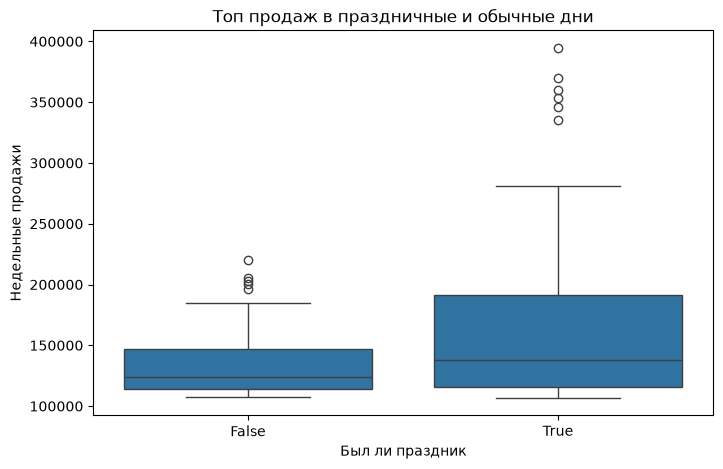

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(data=top_sales_grouped, x='is_holiday', y='weekly_sales')
plt.title('Топ продаж в праздничные и обычные дни')
plt.xlabel('Был ли праздник')
plt.ylabel('Недельные продажи')
plt.show()

В праздники медианное значение продаж обычно выше прочих дней, также праздничным более присущи аномально высокие продажи

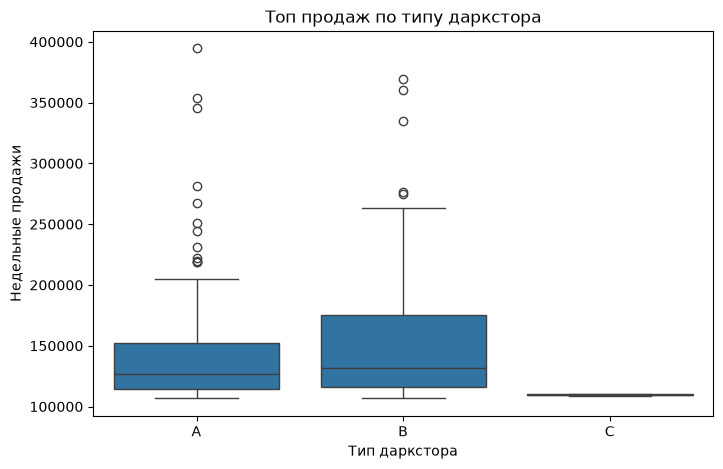

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(data=top_sales_grouped, x='type', y='weekly_sales')
plt.title('Топ продаж по типу даркстора')
plt.xlabel('Тип даркстора')
plt.ylabel('Недельные продажи')
plt.show()

Наибольшие значения недельных продаж приходятся на типы дарксторов А и B, при этом тип B демонстрирует немного большие значения.

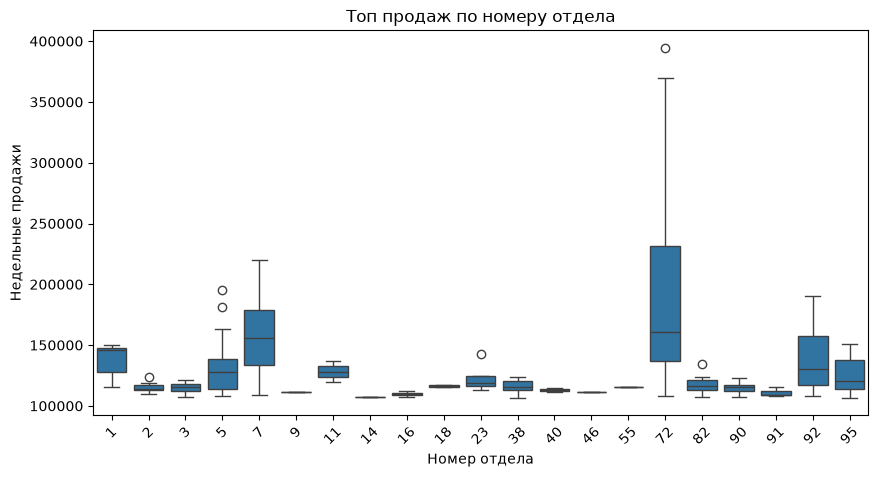

In [50]:
plt.figure(figsize=(10,5))
sns.boxplot(data=top_sales_grouped, x='dept', y='weekly_sales')
plt.title('Топ продаж по номеру отдела')
plt.xlabel('Номер отдела')
plt.ylabel('Недельные продажи')
plt.xticks(rotation=45)
plt.show()

Аномльно высокие значения продаж по большей части приходятся на отдел 72. Также стоит отетить 7 отдел, как демонстрирующй относительно высокие продажи

### Шаг 2. Предобработка признаков и feature engineering

**Задача:** реализуйте функцию `create_temporal_features` для извлечения временных признаков из столбца `Date`.

Извлеките из даты:
- Месяц (`month`).
- Квартал (`quarter`).
- Год (`year`).

Эти признаки помогут модели уловить сезонные паттерны.

In [54]:
def create_temporal_features(df) -> pd.DataFrame:
    df_copy  = df.copy()
    df_copy['date'] = pd.to_datetime(df_copy['date'])
    df_copy['month'] = df_copy['date'].dt.month
    df_copy['quarter'] = df_copy['date'].dt.quarter
    df_copy['year'] = df_copy['date'].dt.year

    return df_copy

df = create_temporal_features(df)

In [55]:
assert 'month' in df.columns, 'Месяц не создан!'
assert 'quarter' in df.columns, 'Квартал не создан!'
assert 'year' in df.columns, 'Год не создан!'

**Задача:** cоздайте агрегированные признаки в функции `create_avg_sales_feature` — средние продажи по комбинации «даркстор и отдел».

**Важно: Избегайте утечки данных!**

При создании агрегатов для каждой строки используйте только данные **до** этой даты:
- Для даты 2025-09-08 считайте среднее по данным с начала до 2025-09-07 включительно.
- Для даты 2025-09-15 считайте среднее по данным с начала до 2025-09-14 включительно.

Это критически важно, чтобы модель не использовала информацию из будущего!

In [57]:
def create_avg_sales_feature(df):
    df_copy = df.copy()
    df_copy = df_copy.sort_values(['store', 'dept', 'date'])

    expanding_mean = df_copy.groupby(['store', 'dept'])['weekly_sales'].expanding().mean()

    df_copy['avg_sales_before'] = (
        expanding_mean
        .groupby(level=['store', 'dept'])
        .shift(1)
        .values
    )
 
    return df_copy

df = create_avg_sales_feature(df)

In [58]:
assert 'avg_sales_before' in df.columns, 'Признак средних продаж не создан!'

**Задача:** создайте лаговые признаки в функции `create_lag_features` — продажи 1, 2 и 4 недели назад.

Лаговые признаки позволяют модели учитывать историю продаж:
- `sales_1week_ago` — продажи неделю назад.
- `sales_2week_ago` — продажи 2 недели назад.
- `sales_4week_ago` — продажи 4 недели назад.

Это одни из самых важных признаков для прогнозирования временных рядов!

In [60]:
def create_lag_features(df):
    df_copy = df.copy()
    df_copy = df_copy.sort_values(['store', 'dept', 'date'])

    df_copy['sales_1week_ago'] = df_copy.groupby(['store', 'dept'])['weekly_sales'].shift(1)
    df_copy['sales_2week_ago'] = df_copy.groupby(['store', 'dept'])['weekly_sales'].shift(2)
    df_copy['sales_4week_ago'] = df_copy.groupby(['store', 'dept'])['weekly_sales'].shift(4)

    return df_copy
    
df = create_lag_features(df)

In [61]:
assert 'sales_1week_ago' in df.columns, 'Признак sales_1week_ago не создан!'
assert 'sales_2week_ago' in df.columns, 'Признак sales_2week_ago не создан!'
assert 'sales_4week_ago' in df.columns, 'Признак sales_4week_ago не создан!'

**Задача:** cоздайте признаки скользящего среднего продаж за последние 2 и 4 недели в функции `create_rolling_features`.

Скользящее среднее сглаживает колебания и показывает общий тренд:
- `mean_sales_2week` — среднее продаж за последние 2 недели.
- `mean_sales_4week` — среднее продаж за последние 4 недели.

Эти признаки помогают уловить краткосрочные и среднесрочные тренды.

In [63]:
def create_rolling_features(df):
    df_copy = df.copy()
    df_copy = df_copy.sort_values(['store', 'dept', 'date'])

    df_copy['mean_sales_2week'] = (
        df_copy.groupby(['store', 'dept'])['weekly_sales']
        .rolling(window=2, min_periods=2)
        .mean()
        .groupby(level=[0, 1])
        .shift(1)
        .reset_index(level=[0, 1], drop=True)
    )

    df_copy['mean_sales_4week'] = (
        df_copy.groupby(['store', 'dept'])['weekly_sales']
        .rolling(window=4, min_periods=4)
        .mean()
        .groupby(level=[0, 1])
        .shift(1)
        .reset_index(level=[0, 1], drop=True)
    )

    return df_copy

df = create_rolling_features(df)

In [64]:
assert 'mean_sales_2week' in df.columns, 'Признак mean_sales_2week не создан!'
assert 'mean_sales_4week' in df.columns, 'Признак mean_sales_4week не создан!'

**Задача:** удалите строки с пропусками.

После создания лаговых и агрегированных признаков неизбежно появятся пропуски (особенно для первых недель, где нет истории). Удалите такие строки с помощью `dropna()`.

In [66]:
df = df.dropna()

In [67]:
df.info()

<class 'pandas.DataFrame'>
Index: 407188 entries, 12681 to 421569
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype        
---  ------            --------------   -----        
 0   store             407188 non-null  int64        
 1   dept              407188 non-null  int64        
 2   date              407188 non-null  datetime64[s]
 3   weekly_sales      407188 non-null  float64      
 4   is_holiday        407188 non-null  bool         
 5   type              407188 non-null  str          
 6   size              407188 non-null  int64        
 7   temperature       407188 non-null  float64      
 8   fuel_price        407188 non-null  float64      
 9   factor1           407188 non-null  float64      
 10  factor2           407188 non-null  float64      
 11  factor3           407188 non-null  float64      
 12  factor4           407188 non-null  float64      
 13  factor5           407188 non-null  float64      
 14  cpi               407188 non-nul

### Шаг 3. Мониторинг стабильности признаков

**Задача:** разделите данные на обучающую и валидационную выборки **по времени**.

Разделение:
- **Обучение**: февраль 2023 — август 2025.
- **Валидация**: сентябрь 2025 — октябрь 2025.

Такое разделение имитирует реальное применение модели: обучаем на прошлых данных, проверяем на будущих.

In [70]:
df_train = df[df['date'] < '2025-09-01']
df_val = df[df['date'] >= '2025-09-01']

In [71]:
print(f"Период в тренировочной выборке: {df_train['date'].dt.date.min()} - {df_train['date'].dt.date.max()}")
print(f"Период в валидационной выборке: {df_val['date'].dt.date.min()} - {df_val['date'].dt.date.max()}")

Период в тренировочной выборке: 2023-03-05 - 2025-08-31
Период в валидационной выборке: 2025-09-07 - 2025-10-26


In [72]:
print(f"Количество записей в тренировочной выборке {len(df_train)} ({len(df_train)/len(df)*100:.2f}%)")
print(f"Количество записей в валидационной выборке {len(df_val)} ({len(df_val)/len(df)*100:.2f}%)")

Количество записей в тренировочной выборке 383541 (94.19%)
Количество записей в валидационной выборке 23647 (5.81%)


**Задача:** рассчитайте PSI для всех признаков.

PSI измеряет стабильность распределения признака между обучающей и валидационной выборками:
- **PSI < 0.1** — признак стабилен, можно использовать.
- **0.1 ≤ PSI < 0.2** — умеренный дрейф, требуется внимание.
- **PSI ≥ 0.2** — значительный дрейф, признак нестабилен.

In [74]:
cols = list(set(df_train.columns) - set(['date', 'year', 'month', 'quarter', 'type']))

In [75]:
def calculate_psi(expected, actual, buckets=10, epsilon=1e-10):
    breaks = np.linspace(min(min(expected), min(actual)),
                         max(max(expected), max(actual)), buckets + 1)

    expected_bins = np.histogram(expected, bins=breaks)[0] / len(expected)
    actual_bins = np.histogram(actual, bins=breaks)[0] / len(actual)

    expected_bins = np.where(expected_bins == 0, epsilon, expected_bins)
    actual_bins = np.where(actual_bins == 0, epsilon, actual_bins)

    psi = sum((actual_bins[i] - expected_bins[i]) * np.log(actual_bins[i] / expected_bins[i])
              for i in range(buckets))

    return psi

In [76]:
for_del_cols = []

for col in cols:
    psi = calculate_psi(df_train[col], df_val[col])
    print(f"PSI для признака {col}: {psi:.3f}")
    
    for_del_cols.append(col) if psi >= 0.2 else ...
    

PSI для признака size: 0.000
PSI для признака mean_sales_2week: 0.002
PSI для признака fuel_price: 11.799
PSI для признака temperature: 3.121
PSI для признака dept: 0.001
PSI для признака cpi: 1.045
PSI для признака factor4: 0.278
PSI для признака sales_1week_ago: 0.004
PSI для признака factor2: 0.450
PSI для признака unemployment: 1.457
PSI для признака sales_4week_ago: 0.005
PSI для признака store: 0.000
PSI для признака factor1: 0.332
PSI для признака avg_sales_before: 0.002
PSI для признака factor3: 0.118
PSI для признака sales_2week_ago: 0.004
PSI для признака weekly_sales: 0.005
PSI для признака mean_sales_4week: 0.002
PSI для признака is_holiday: 0.049
PSI для признака factor5: 0.141


**Задача:** интерпретируйте результаты PSI.

Проанализируйте полученные значения PSI:
- Какие признаки стабильны?
- Для каких признаков наблюдается дрейф?

Визуализируйте распределения признаков с высоким PSI на обучении и валидации для лучшего понимания.

Стабильными являются признаки:
  - factor3
  - sales_2week_ago
  - is_holiday
  - factor5
  - store
  - size
  - mean_sales_2week
  - mean_sales_4week
  - sales_1week_ago
  - avg_sales_before
  - dept
  - sales_4week_ago

Значительно дрейфующими и потому непригодными оказались признаки:
  - factor1
  - fuel_price
  - factor4
  - unemployment
  - temperature
  - cpi
  - factor2

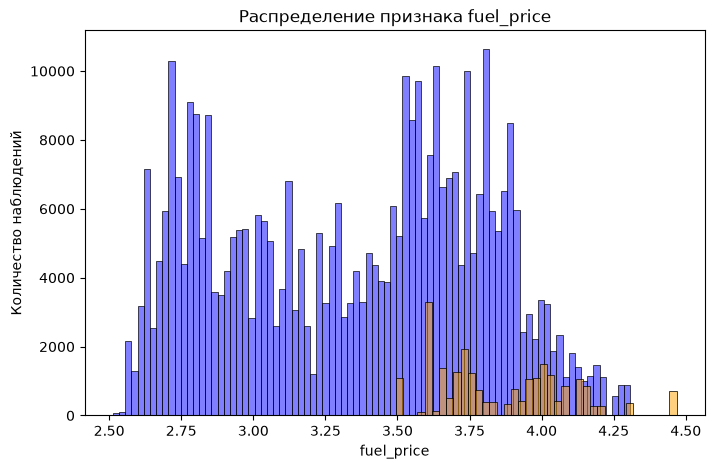

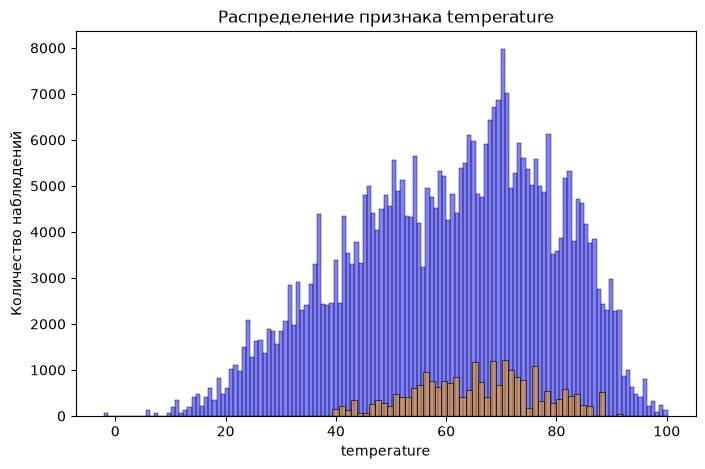

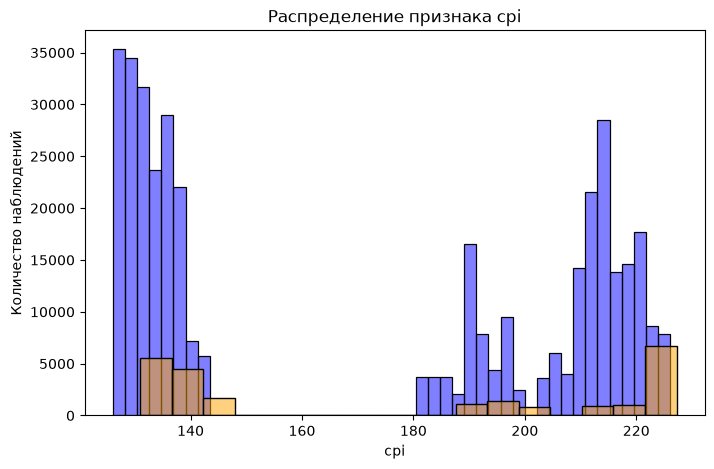

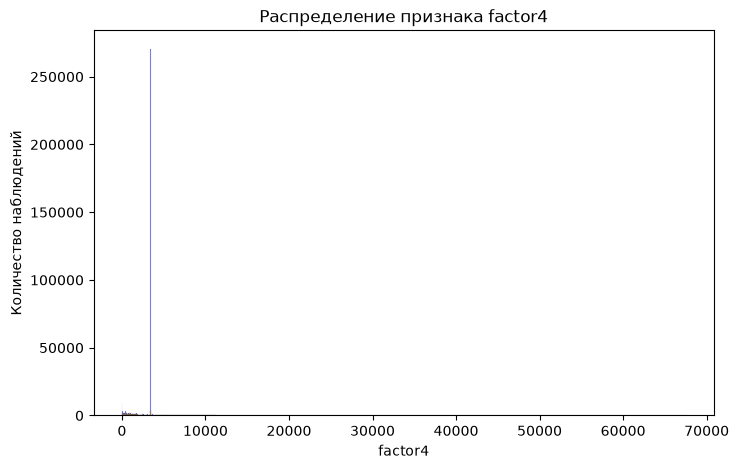

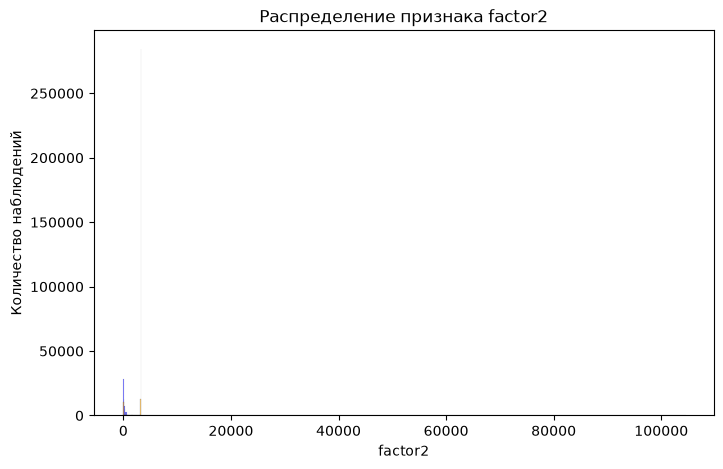

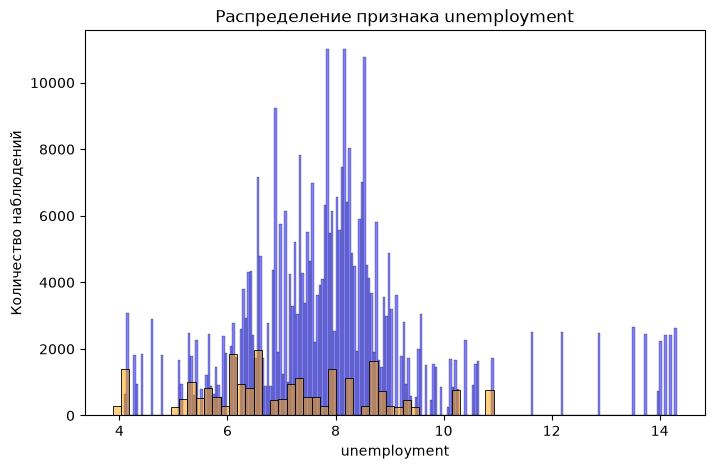

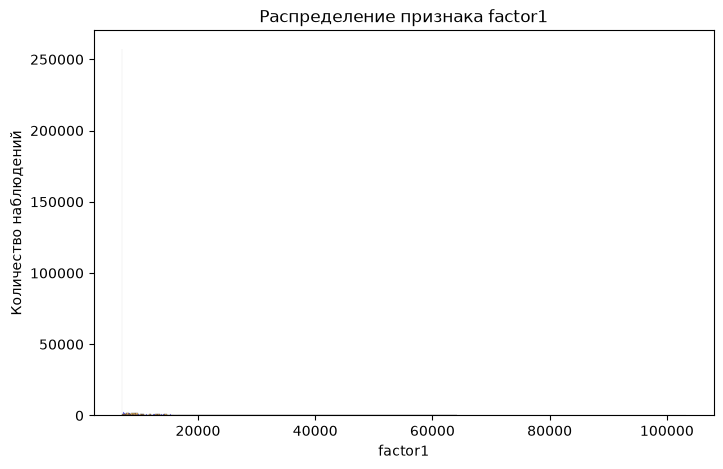

In [79]:
for col in for_del_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_train[col], alpha=0.5, color='blue')
    sns.histplot(data=df_val[col], alpha=0.5, color='orange')
    plt.title(f'Распределение признака {col}')
    plt.xlabel(col)
    plt.ylabel('Количество наблюдений')
    plt.show()

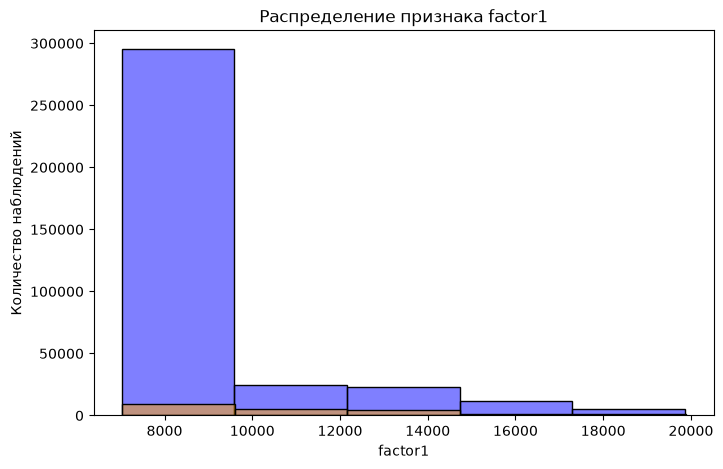

In [80]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_train[df_train['factor1']<20000]['factor1'], alpha=0.5, color='blue', bins=5)
sns.histplot(data=df_val[df_val['factor1']<20000]['factor1'], alpha=0.5, color='orange', bins=5)
plt.title(f'Распределение признака factor1')
plt.xlabel('factor1')
plt.ylabel('Количество наблюдений')
plt.show()

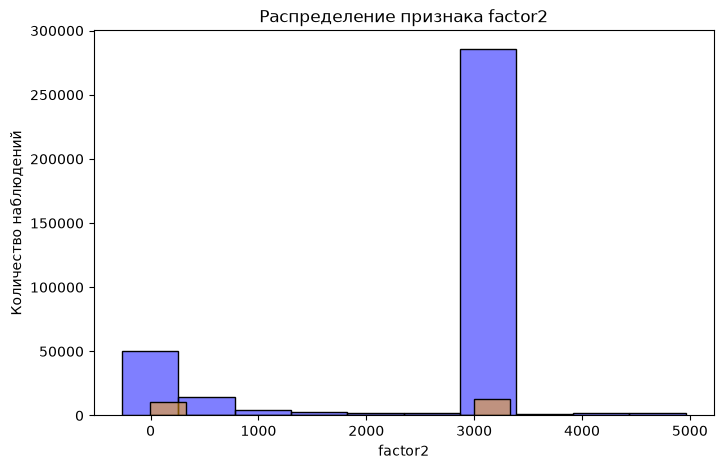

In [81]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_train[df_train['factor2']<5000]['factor2'], alpha=0.5, color='blue', bins=10)
sns.histplot(data=df_val[df_val['factor2']<5000]['factor2'], alpha=0.5, color='orange', bins=10)
plt.title(f'Распределение признака factor2')
plt.xlabel('factor2')
plt.ylabel('Количество наблюдений')
plt.show()

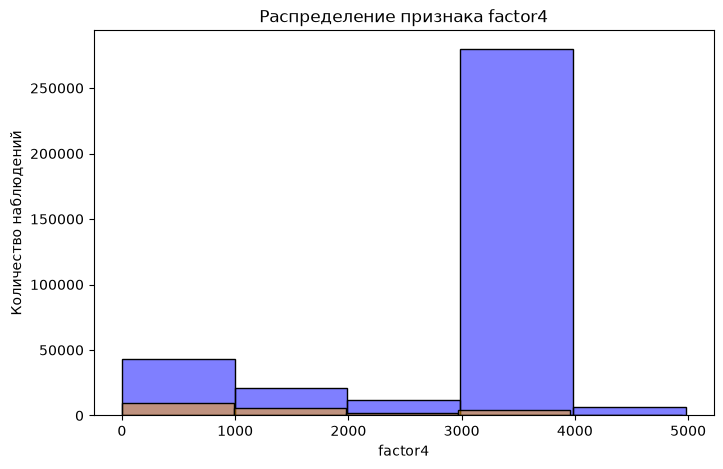

In [82]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_train[df_train['factor4']<5000]['factor4'], alpha=0.5, color='blue', bins=5)
sns.histplot(data=df_val[df_val['factor4']<5000]['factor4'], alpha=0.5, color='orange', bins=5)
plt.title(f'Распределение признака factor4')
plt.xlabel('factor4')
plt.ylabel('Количество наблюдений')
plt.show()

Для непригодных из-за дрейфа признаков блыи построены графики распределния из которых можно увидеть, что распредления для тренировочной и валидационных выборок действительно различаются

**Задача:** удалите признаки с PSI ≥ 0.2.

Признаки с высоким PSI нестабильны и могут ухудшить качество модели в будущем. Удалите их из обучающей и валидационной выборок.

In [85]:
for_del_cols.append('date')

In [86]:
df_train = df_train.drop(columns=for_del_cols)
df_val = df_val.drop(columns=for_del_cols)

### Шаг 4. Обучение модели CatBoost

**Задача:** обучите модель CatBoost.

Используйте **обучающую** выборку.

In [89]:
X_train = df_train.drop(columns='weekly_sales')
y_train = df_train['weekly_sales']

X_val = df_val.drop(columns='weekly_sales')
y_val = df_val['weekly_sales']

In [91]:
categorical_features = ['type', 'month', 'quarter', 'year', 'store', 'dept']
catboost = CatBoostRegressor(random_state=RANDOM_STATE, cat_features=categorical_features)

In [92]:
catboost.fit(X_train, y_train)

Learning rate set to 0.104815
0:	learn: 20692.4876050	total: 620ms	remaining: 10m 19s
1:	learn: 18818.4294047	total: 2.85s	remaining: 23m 41s
2:	learn: 17155.9919666	total: 3.71s	remaining: 20m 32s
3:	learn: 15677.3724838	total: 4.71s	remaining: 19m 33s
4:	learn: 14366.2703070	total: 5.57s	remaining: 18m 27s
5:	learn: 13199.4328885	total: 6.45s	remaining: 17m 47s
6:	learn: 12175.5129242	total: 7.09s	remaining: 16m 46s
7:	learn: 11271.5447744	total: 7.52s	remaining: 15m 32s
8:	learn: 10487.0741438	total: 7.88s	remaining: 14m 28s
9:	learn: 9803.1100703	total: 8.24s	remaining: 13m 35s
10:	learn: 9212.7581901	total: 8.63s	remaining: 12m 55s
11:	learn: 8691.2538909	total: 9.05s	remaining: 12m 25s
12:	learn: 8254.1251221	total: 9.36s	remaining: 11m 50s
13:	learn: 7874.2820680	total: 9.73s	remaining: 11m 25s
14:	learn: 7550.9878593	total: 10.2s	remaining: 11m 6s
15:	learn: 7273.6119444	total: 10.5s	remaining: 10m 47s
16:	learn: 7035.5700380	total: 10.9s	remaining: 10m 32s
17:	learn: 6836.0552

CatBoostRegressor(cat_features=['type', 'month', 'quarter', 'year', 'store', 'dept'], loss_function='RMSE', random_state=42)

In [93]:
y_pred = catboost.predict(X_val)

**Задача:** оцените качество модели на валидационной выборке.

Используйте метрики:
- **MAE**.
- **RMSE**.
- **R²**.

In [95]:
print(f'R2: {r2_score(y_val, y_pred):.3f}')
print(f'MAE: {mean_absolute_error(y_val, y_pred):.3f}')
print(f'RMSE: {root_mean_squared_error(y_val, y_pred):.3f}')

R2: 0.980
MAE: 1449.266
RMSE: 3060.920


* Модель объясняет 98% дисперсии целевой переменной - отличный результат  
* В среднем предсказания модели отличаются от реальных значений на 1449
* RMSE в 2.1 раза превосходит MAE, что свидетельствует о наличии в данных выборосов и как следствие нескольких крупных ошибок в предсказаниях

**Задача:** проанализируйте важность признаков.

Она показывает, какие признаки наиболее важны для модели:
- Проверьте, нет ли в топе признаков, которые могут приводить к утечке данных.
- Посмотрите, какие признаки действительно влияют на продажи.


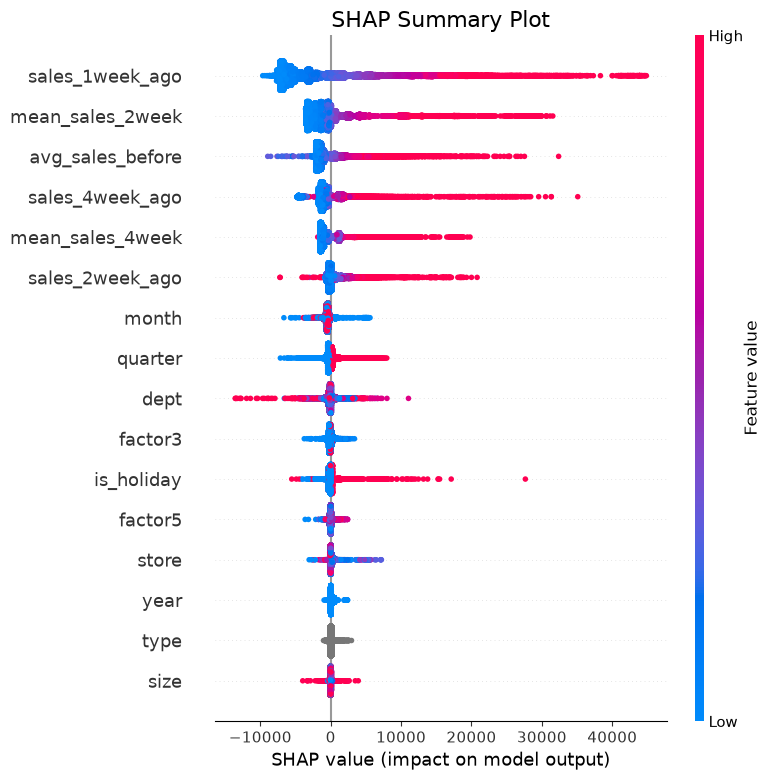

In [98]:
explainer = shap.TreeExplainer(catboost)
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_val, show=False)
plt.title(f"SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

Наибольшее влияние на предсказания оказывают признаки, отражающие продажи в предыдущие периоды, зависимость прямая.

**Задача:** сохраните обученную модель в S3.

Модель нужно сохранить для дальнейшего использования в batch-инференсе. Код уже реализован, необходимо просто его запустить.

**Важно:** не указывайте секреты явно в ноутбуке, используйте переменные окружения.

In [98]:
# Создаём клиент для подключения к S3
s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=os.getenv('S3_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    region_name='ru-central1'
)

# Сохраняем модель в буфер
filebuffer = io.BytesIO()
pickle.dump(catboost, filebuffer)
filebuffer.seek(0)

# Загружаем в S3
s3_client.upload_fileobj(
    Fileobj=filebuffer,
    Bucket=os.getenv('S3_BUCKET'),
    Key='catboost_model.pkl'
)

print(f"Модель успешно загружена в {os.getenv('S3_BUCKET')}/catboost_model.pkl")

Модель успешно загружена в s3-ds-20260604-9358961f1d/catboost_model.pkl
